# Herramientas de Frontera Dynare — puremacro 2.0 y 2.1

**¿Podemos resolver, simular y estimar modelos macroeconómicos DSGE avanzados completamente en Python puro, sin MATLAB ni compilación C++?**

Dynare ha sido durante dos décadas el estándar para la modelización macroeconómica DSGE. Sin embargo, su flujo de trabajo tradicional requiere licencias comerciales de MATLAB o instalaciones complejas de C++ MEX.

Con **puremacro 2.0 y 2.1**, investigadores y estudiantes pueden cargar archivos `.mod` de Dynare directamente, calcular reglas de decisión lineales y de segundo orden con poda (*pruning*), descomposición de varianza de errores de pronóstico (FEVD), descomposición histórica de shocks mediante suavizador de Kalman, restricciones ocasionalmente activas (OccBin / Zero Lower Bound), simulaciones no lineales deterministas (*perfect foresight*) y estimación Bayesiana MCMC completa—todo en **Python puro**, compatible con navegadores WebAssembly (JupyterLite) y tablets sin instalación previa.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.dsge import (
    load_mod,
    build_dynare,
    compute_fevd,
    compute_shock_decomposition,
    solve_occbin,
    OccBinConstraint,
    solve_perfect_foresight,
)

## 1. Carga y Resolución del Modelo de Smets y Wouters (2007) (.mod)

Cargamos directamente el archivo canonical de Johannes Pfeifer para el modelo de Smets & Wouters (2007, *AER*) (`sw07_pfeifer.mod`).
`puremacro.dsge.load_mod` procesa todas las ecuaciones, variables predeterminadas, estados estacionarios y bloques de shocks, identificando automáticamente los 15 estados y 25 variables de salto.

Variables endógenas  : 40
Shocks estructurales : 7
Estados predeterminados: 15
Variables de salto   : 25


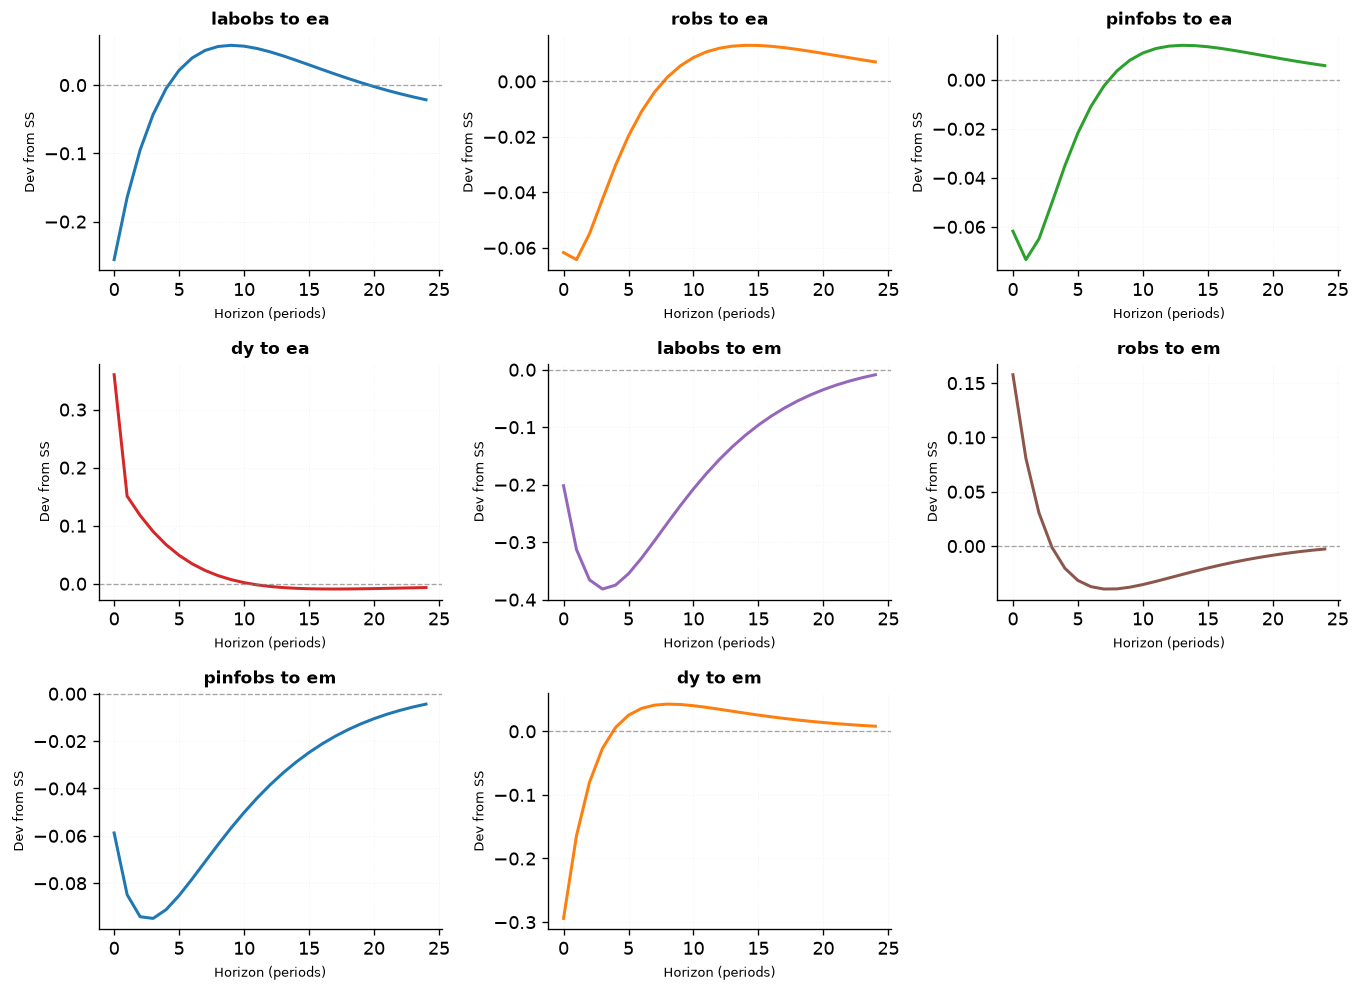

In [2]:
import puremacro.dsge
# Resolve the reference .mod from the installed package so the notebook runs
# from any working directory (tools/build_notebooks.py uses notebooks/ as cwd).
mod_path = Path(puremacro.dsge.__file__).parent / "_references" / "sw07_pfeifer.mod"
m = load_mod(mod_path, order=1)

print(f"Variables endógenas  : {len(m.variables)}")
print(f"Shocks estructurales : {len(m.shocks)}")
print(f"Estados predeterminados: {m.n_states}")
print(f"Variables de salto   : {m.n_controls}")

# Ejecutamos stoch_simul para obtener reglas de decisión, momentos teóricos e IRFs
sim_res = m.stoch_simul(irf=24)
fig_irfs = sim_res.plot(variables=["labobs", "robs", "pinfobs", "dy"], shocks=["ea", "em"])
plt.show()

## 2. Descomposición de Varianza del Error de Pronóstico (FEVD)

La descomposición FEVD cuantifica el porcentaje de la varianza del error de predicción atribuible a cada perturbación estructural en horizontes $h \in \{1, 4, 8, 16, \dots, \infty\}$.

Mediante la representación de medias móviles ortogonalizadas:
$$ y_{t+h} - \mathbb{E}_t y_{t+h} = \sum_{k=0}^{h-1} \Psi_k u_{t+h-k} $$
Puremacro garantiza numéricamente con precisión de máquina que la suma de participaciones es exactamente igual a 1.0 (100%) para cada variable y horizonte.

FORECAST ERROR VARIANCE DECOMPOSITION (Dynare Format)
                         ea        eb        eg       eqs        em     epinf        ew
Variable Horizon                                                                       
labobs   1         0.003423  0.978959  0.009319  0.006104  0.002133  0.000012  0.000050
robs     1         0.001503  0.987040  0.000353  0.001083  0.009794  0.000092  0.000136
pinfobs  1         0.016270  0.824805  0.000605  0.011356  0.014732  0.124856  0.007377
dy       1         0.003297  0.979260  0.008959  0.006114  0.002204  0.000115  0.000052
dc       1         0.000856  0.996891  0.000388  0.000019  0.001821  0.000024  0.000001
dinve    1         0.000508  0.847182  0.000024  0.148656  0.003495  0.000126  0.000010
dw       1         0.023802  0.622587  0.000047  0.004116  0.004165  0.073775  0.271506
ewma     1         0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  1.000000
epinfma  1         0.000000  0.000000  0.000000  0.000000  0.00000

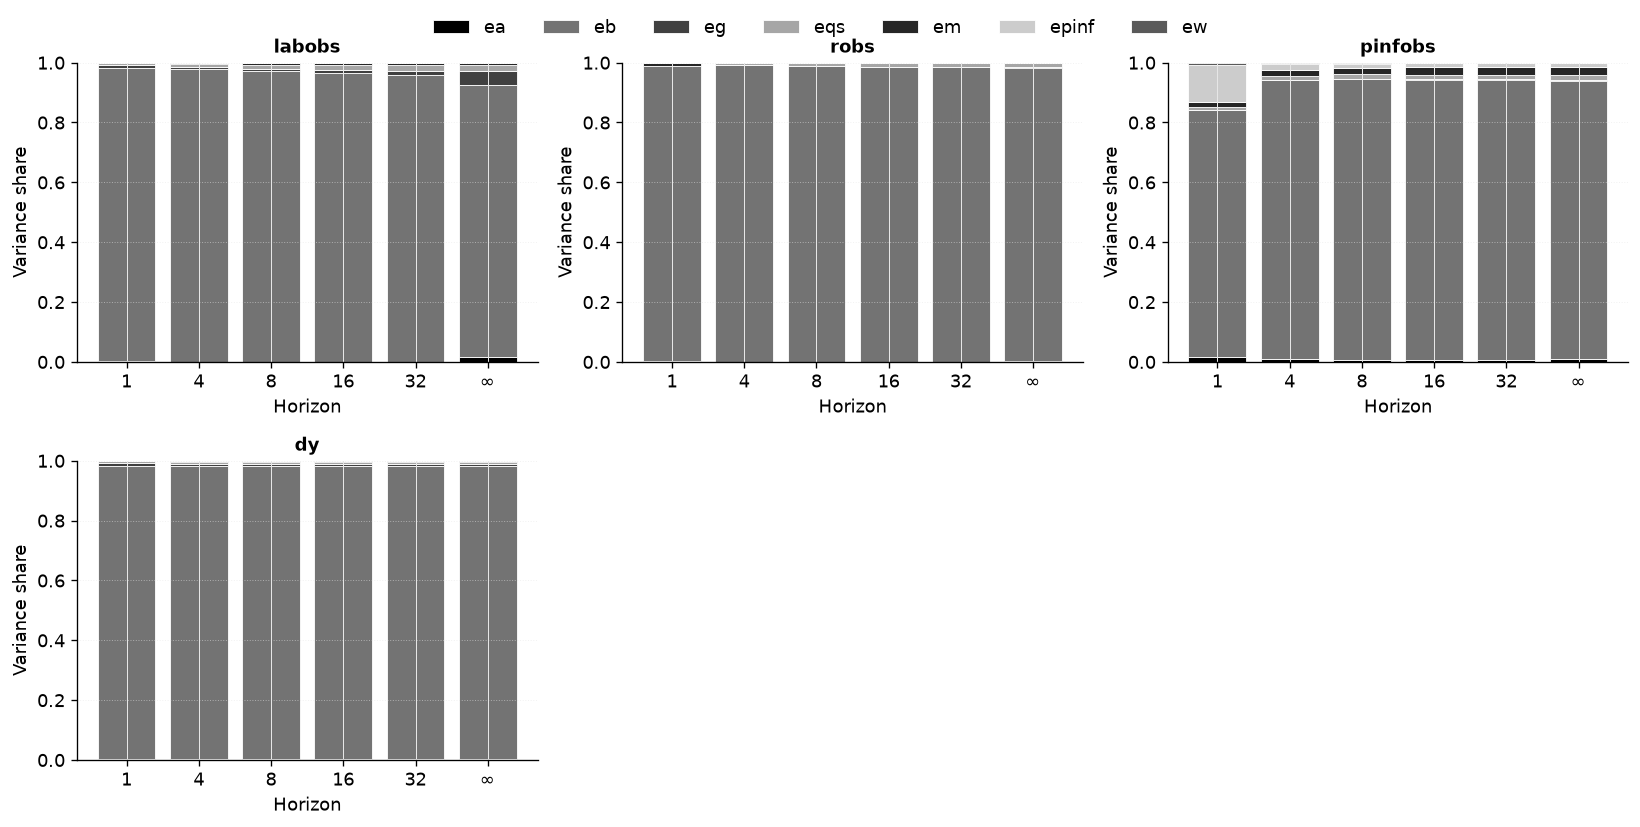

In [3]:
fevd_res = compute_fevd(m, horizons=[1, 4, 8, 16, 32, None])
print(fevd_res.summary())

fig_fevd = fevd_res.plot(variables=["labobs", "robs", "pinfobs", "dy"])
plt.show()

## 3. Descomposición Histórica de Shocks

¿Qué perturbaciones estructurales causaron las fluctuaciones observadas del ciclo económico?
Mediante el suavizador de Kalman (*Kalman smoother*), puremacro reconstruye la trayectoria histórica de cada serie como la suma de:
1. Estado estacionario $\bar{y}$
2. Decaimiento de la condición inicial $C A^t s_0$
3. Contribución acumulada de cada shock estructural $\sum_j \text{Shock}_j(t)$

Datos cargados: 156 trimestres para observables: ['dy', 'dc', 'dinve', 'labobs', 'pinfobs', 'dw', 'robs']
Dimensión de estados suavizados : (156, 15) (trimestres x estados)
Dimensión de shocks suavizados  : (156, 7) (trimestres x shocks)
Variables descompuestas: ['labobs', 'robs', 'pinfobs', 'dy', 'dc', 'dinve', 'dw', 'ewma', 'epinfma', 'zcapf', 'rkf', 'kf', 'pkf', 'cf', 'invef', 'yf', 'labf', 'wf', 'rrf', 'mc', 'zcap', 'rk', 'k', 'pk', 'c', 'inve', 'y', 'lab', 'pinf', 'w', 'r', 'a', 'b', 'g', 'qs', 'ms', 'spinf', 'sw', 'kpf', 'kp']


/Users/jalonso/Documents/RESEARCH/puremacro/puremacro/dsge/_results.py:692: UserWarning: compute_shock_decomposition: the smoothed model path does not reproduce the observed data for dinve (max|residual|=2.595e+00 vs series range 1.845e+01), labobs (max|residual|=1.787e+00 vs series range 1.037e-01), robs (max|residual|=7.501e-01 vs series range 2.391e+00), dw (max|residual|=6.777e-01 vs series range 2.391e+00), dy (max|residual|=5.445e-01 vs series range 2.962e+00) (+2 more). The shock contributions, the initial condition and the steady state therefore do not add up to 'actual' on their own; the gap is reported in the 'residual' column. This is expected when there are more observed series than structural shocks, and a sign of misspecification otherwise.
  return compute_shock_decomposition(self._model, self._data, **kwargs)


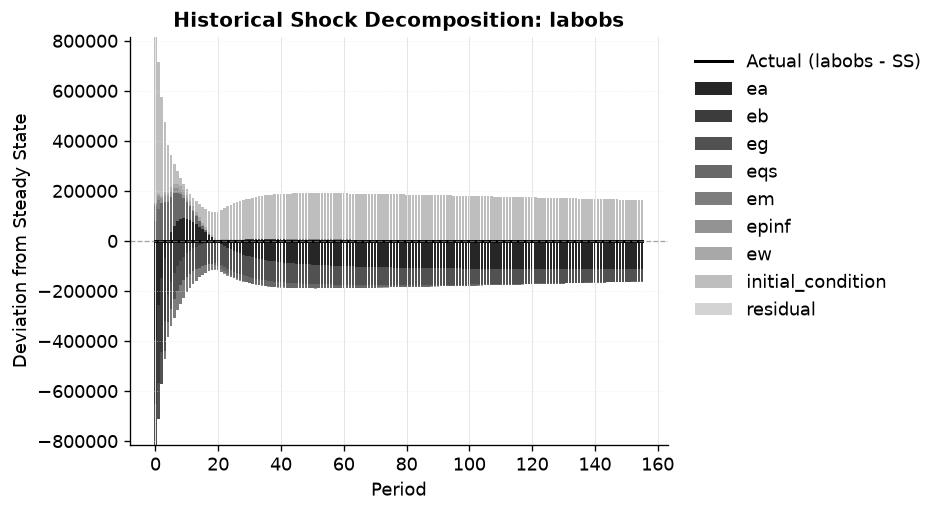

In [4]:
# Cargamos los datos históricos canónicos de Smets-Wouters (2007) para la economía de EE.UU.
csv_path = Path(puremacro.dsge.__file__).parent / "_sw07_data.csv"
raw_data = pd.read_csv(csv_path, comment="#")
rename_map = {
    "gdp_growth": "dy",
    "cons_growth": "dc",
    "inv_growth": "dinve",
    "wage_growth": "dw",
    "log_hours": "labobs",
    "infl": "pinfobs",
    "ffr": "robs",
}
data = raw_data.rename(columns=rename_map)[list(m._varobs)]
print(f"Datos cargados: {data.shape[0]} trimestres para observables: {list(data.columns)}")

# Suavizador de Kalman: extrae estados no observados y perturbaciones estructurales
sm_res = m.smoother(data)
print(f"Dimensión de estados suavizados : {sm_res.states.shape} (trimestres x estados)")
print(f"Dimensión de shocks suavizados  : {sm_res.shocks.shape} (trimestres x shocks)")

# Descomposición histórica de shocks sobre datos reales de EE.UU.
decomp_res = sm_res.shock_decomposition()
print(f"Variables descompuestas: {decomp_res.variable_names}")

fig_decomp = decomp_res.plot(variable="labobs")
plt.show()

## 4. Restricciones Ocasionalmente Activas y Trampa de Liquidez (OccBin)

Cuando el tipo de interés nominal alcanza el límite inferior cero (*Zero Lower Bound*, $r_t \ge -r_{ss}$), la aproximación lineal habitual no es válida.
Siguiendo el algoritmo de Guerrieri & Iacoviello (2015, *JME*), `puremacro.dsge.solve_occbin` resuelve el modelo lineal a trozos mediante iteración regresiva de regímenes.

OCCASIONALLY BINDING CONSTRAINTS REPORT (OccBin - Guerrieri & Iacoviello 2015)
Constraint         : OccBinConstraint(r < -0.01)
Algorithm status   : Converged in 2 iteration(s)
Binding duration   : 5 period(s) out of 40
Regime sequence    : [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...
------------------------------------------------------------------------------
TRAJECTORY SUMMARY STATISTICS
------------------------------------------------------------------------------
    Impact (t=1)       Min       Max      Mean  Final (t=H)
y      -0.071794 -0.071794 -0.000005 -0.005738    -0.000005
pi     -0.022318 -0.022318 -0.000002 -0.002150    -0.000002
r      -0.010000 -0.010000 -0.000004 -0.002297    -0.000004
g      -0.020000 -0.020000 -0.000003 -0.002500    -0.000003


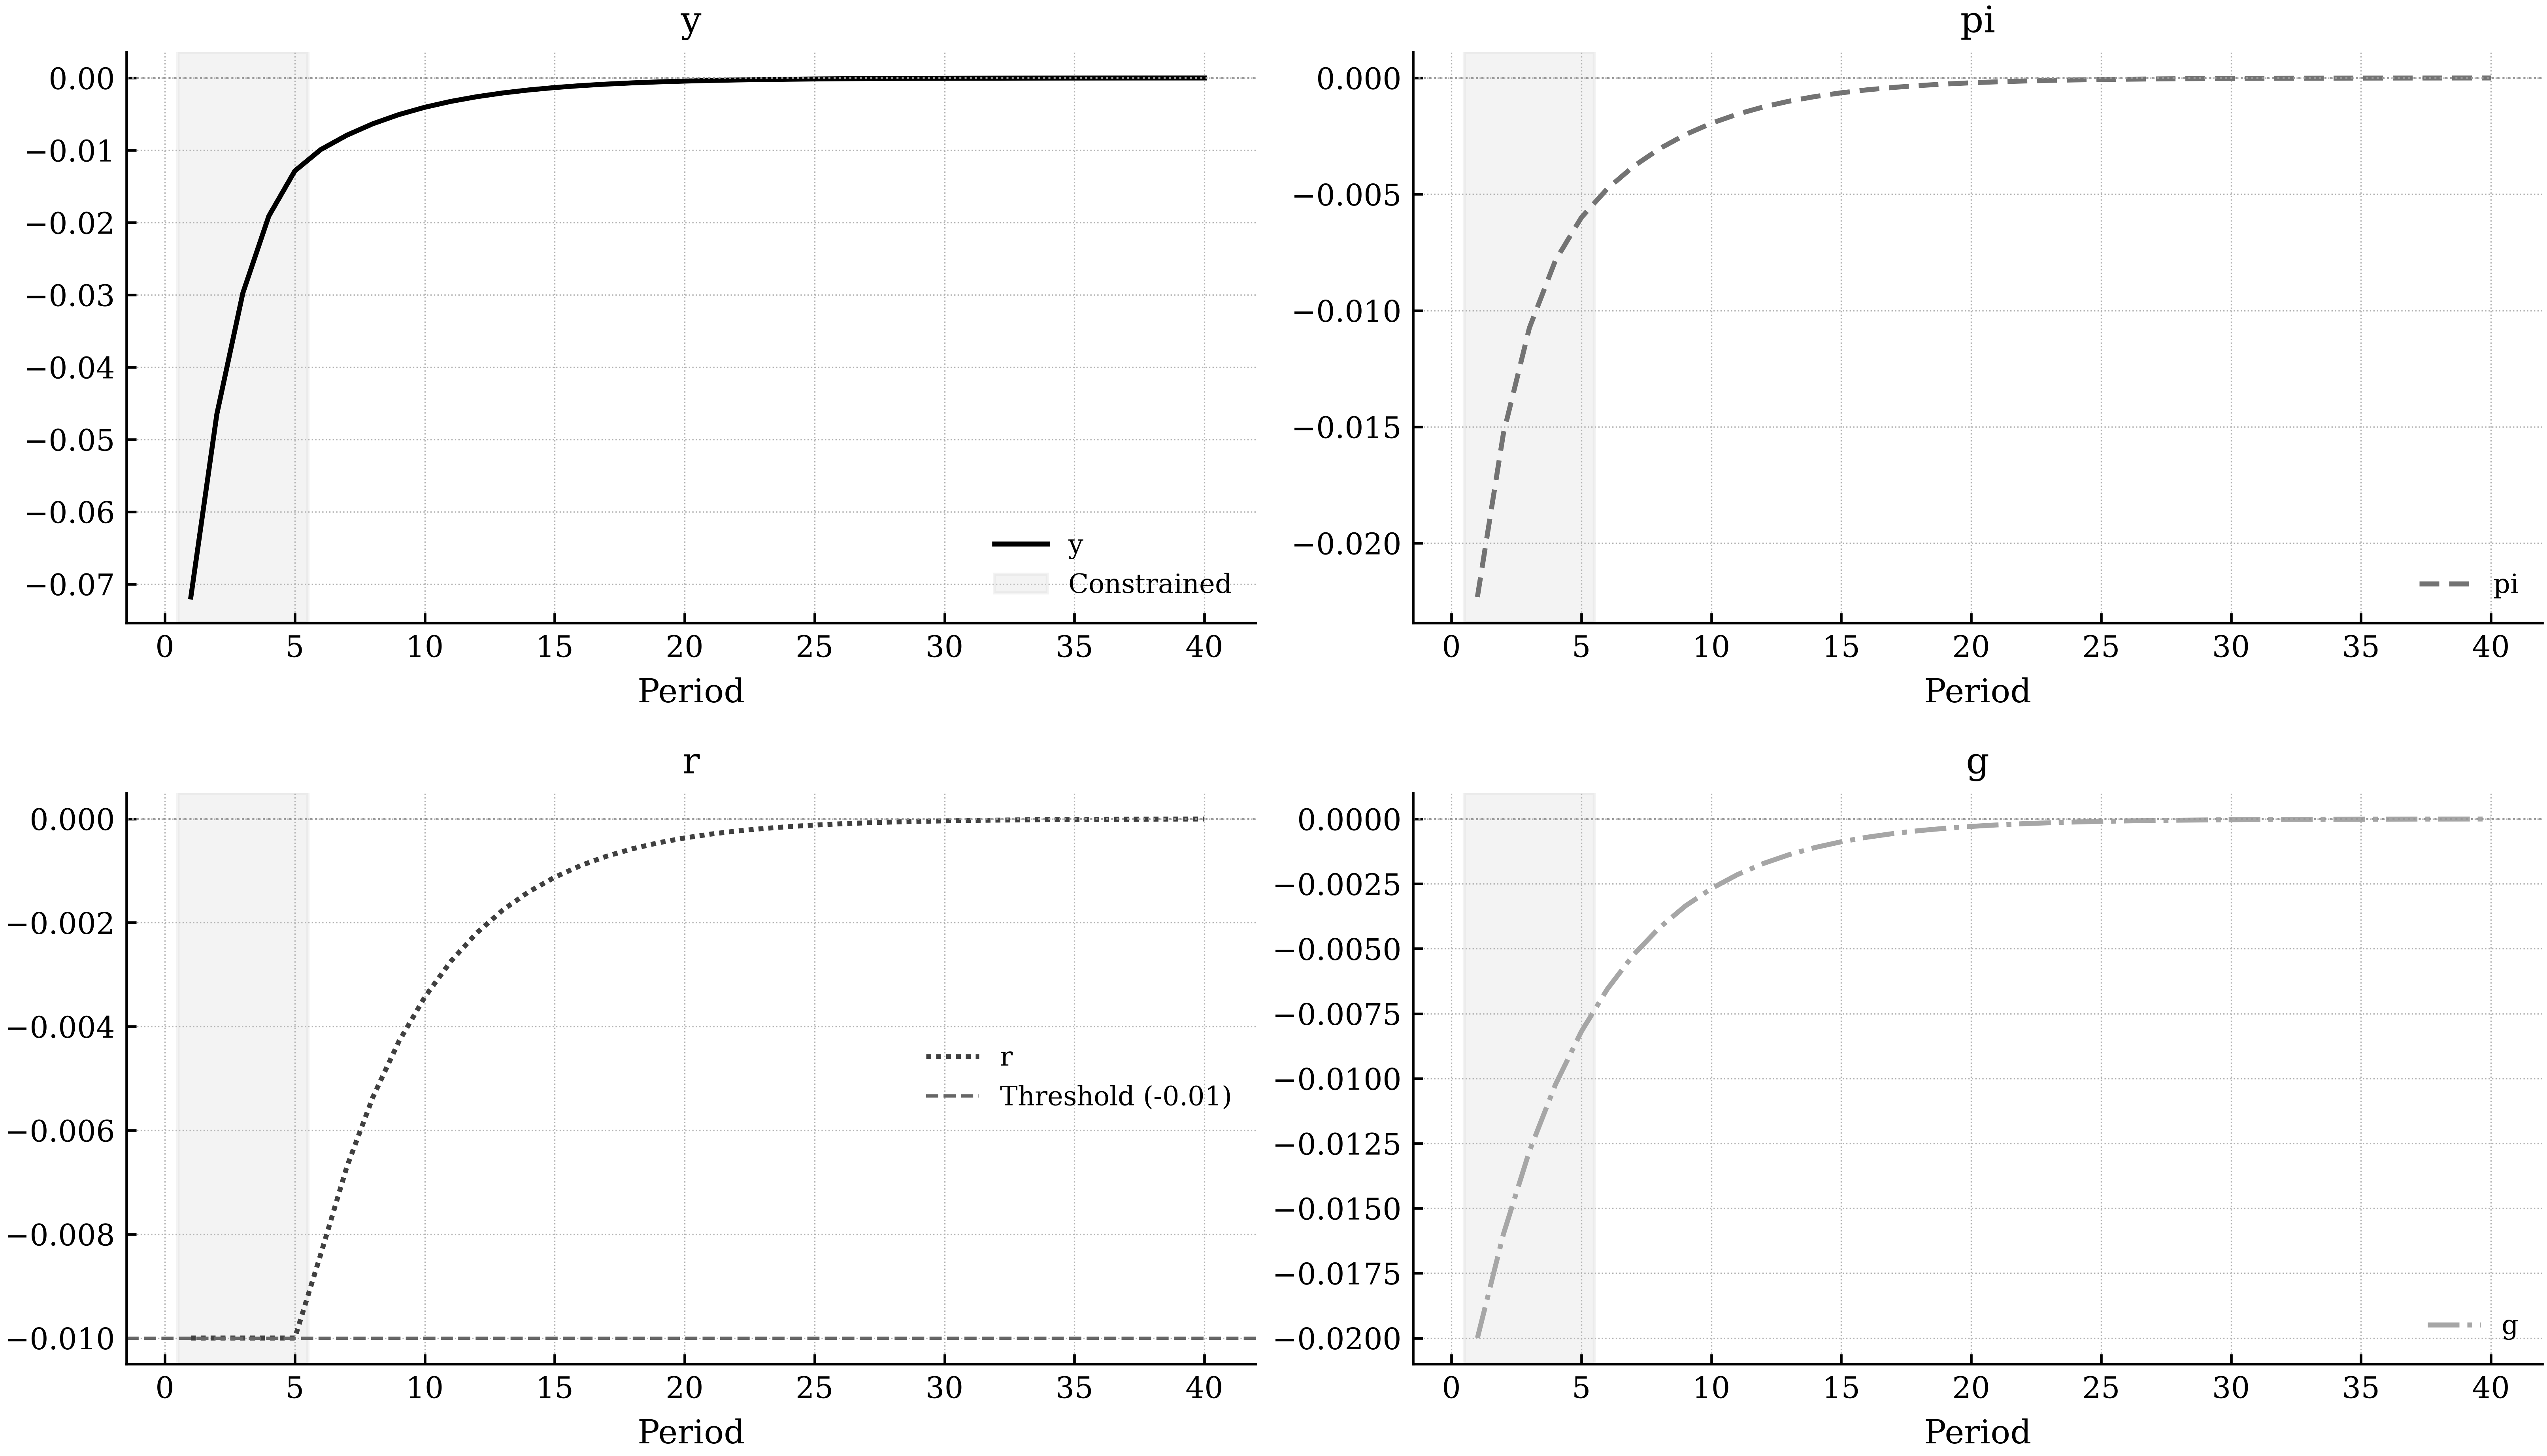

In [5]:
params_nk = {
    "beta": 0.99,
    "sigma": 1.0,
    "kappa": 0.1,
    "phi_pi": 1.5,
    "phi_y": 0.125,
    "rho_g": 0.8,
    "r_ss": 0.01,
}
variables_nk = ["y", "pi", "r", "g"]
shocks_nk = ["eps_r", "eps_g"]
ss_nk = {v: 0.0 for v in variables_nk}

def nk_ref(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - p.phi_pi * curr.pi - p.phi_y * curr.y - shocks_v.eps_r,
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

def nk_cons(lead, curr, lag, shocks_v, p):
    return [
        curr.y - lead.y + (curr.r - lead.pi) / p.sigma - curr.g,
        curr.pi - p.beta * lead.pi - p.kappa * curr.y,
        curr.r - (-p.r_ss),
        curr.g - p.rho_g * lag.g - shocks_v.eps_g,
    ]

ref_mod = build_dynare(nk_ref, variables=variables_nk, shocks=shocks_nk, params=params_nk, steady_state=ss_nk)
cons_mod = build_dynare(nk_cons, variables=variables_nk, shocks=shocks_nk, params=params_nk, steady_state=ss_nk, check_steady_state=False, strict=False)

constraint = OccBinConstraint(variable="r", threshold=-params_nk["r_ss"], operator="<")
shock_seq = np.array([0.0, -0.020])

occ_res = solve_occbin(ref_mod, cons_mod, constraint, shock_sequence=shock_seq, horizon=40)
print(occ_res.summary())

fig_occ = occ_res.plot()
plt.show()

## 5. Simulación No Lineal Determinista (Previsión Perfecta / Perfect Foresight)

Para grandes transiciones lejos del estado estacionario (por ejemplo, convergencia económica, reformas fiscales o transiciones energéticas), las perturbaciones locales pierden validez.
`puremacro.dsge.solve_perfect_foresight` aplica el método de Newton-Raphson apilado (*stacked solver*, Boucekkine 1995, Juillard 1996) con inversión dispersa por bloques.

PERFECT FORESIGHT SIMULATION RESULT
Convergence status  : CONVERGED
Iterations          : 6
Residual norm       : 1.7764e-15  (initial guess: 1.8448e-01)
Terminal error      : 2.1640e-03
Simulation horizon  : 60 periods
Endogenous variables: y_0, y_1
------------------------------------------------------------------------
TRAJECTORY SUMMARY (t=1..T):
         mean       std       min       max   initial  terminal
y_0  1.225387  0.093942  0.878341  1.279941  0.878341  1.279941
y_1  4.153134  0.472062  2.461684  4.431711  2.461684  4.431672


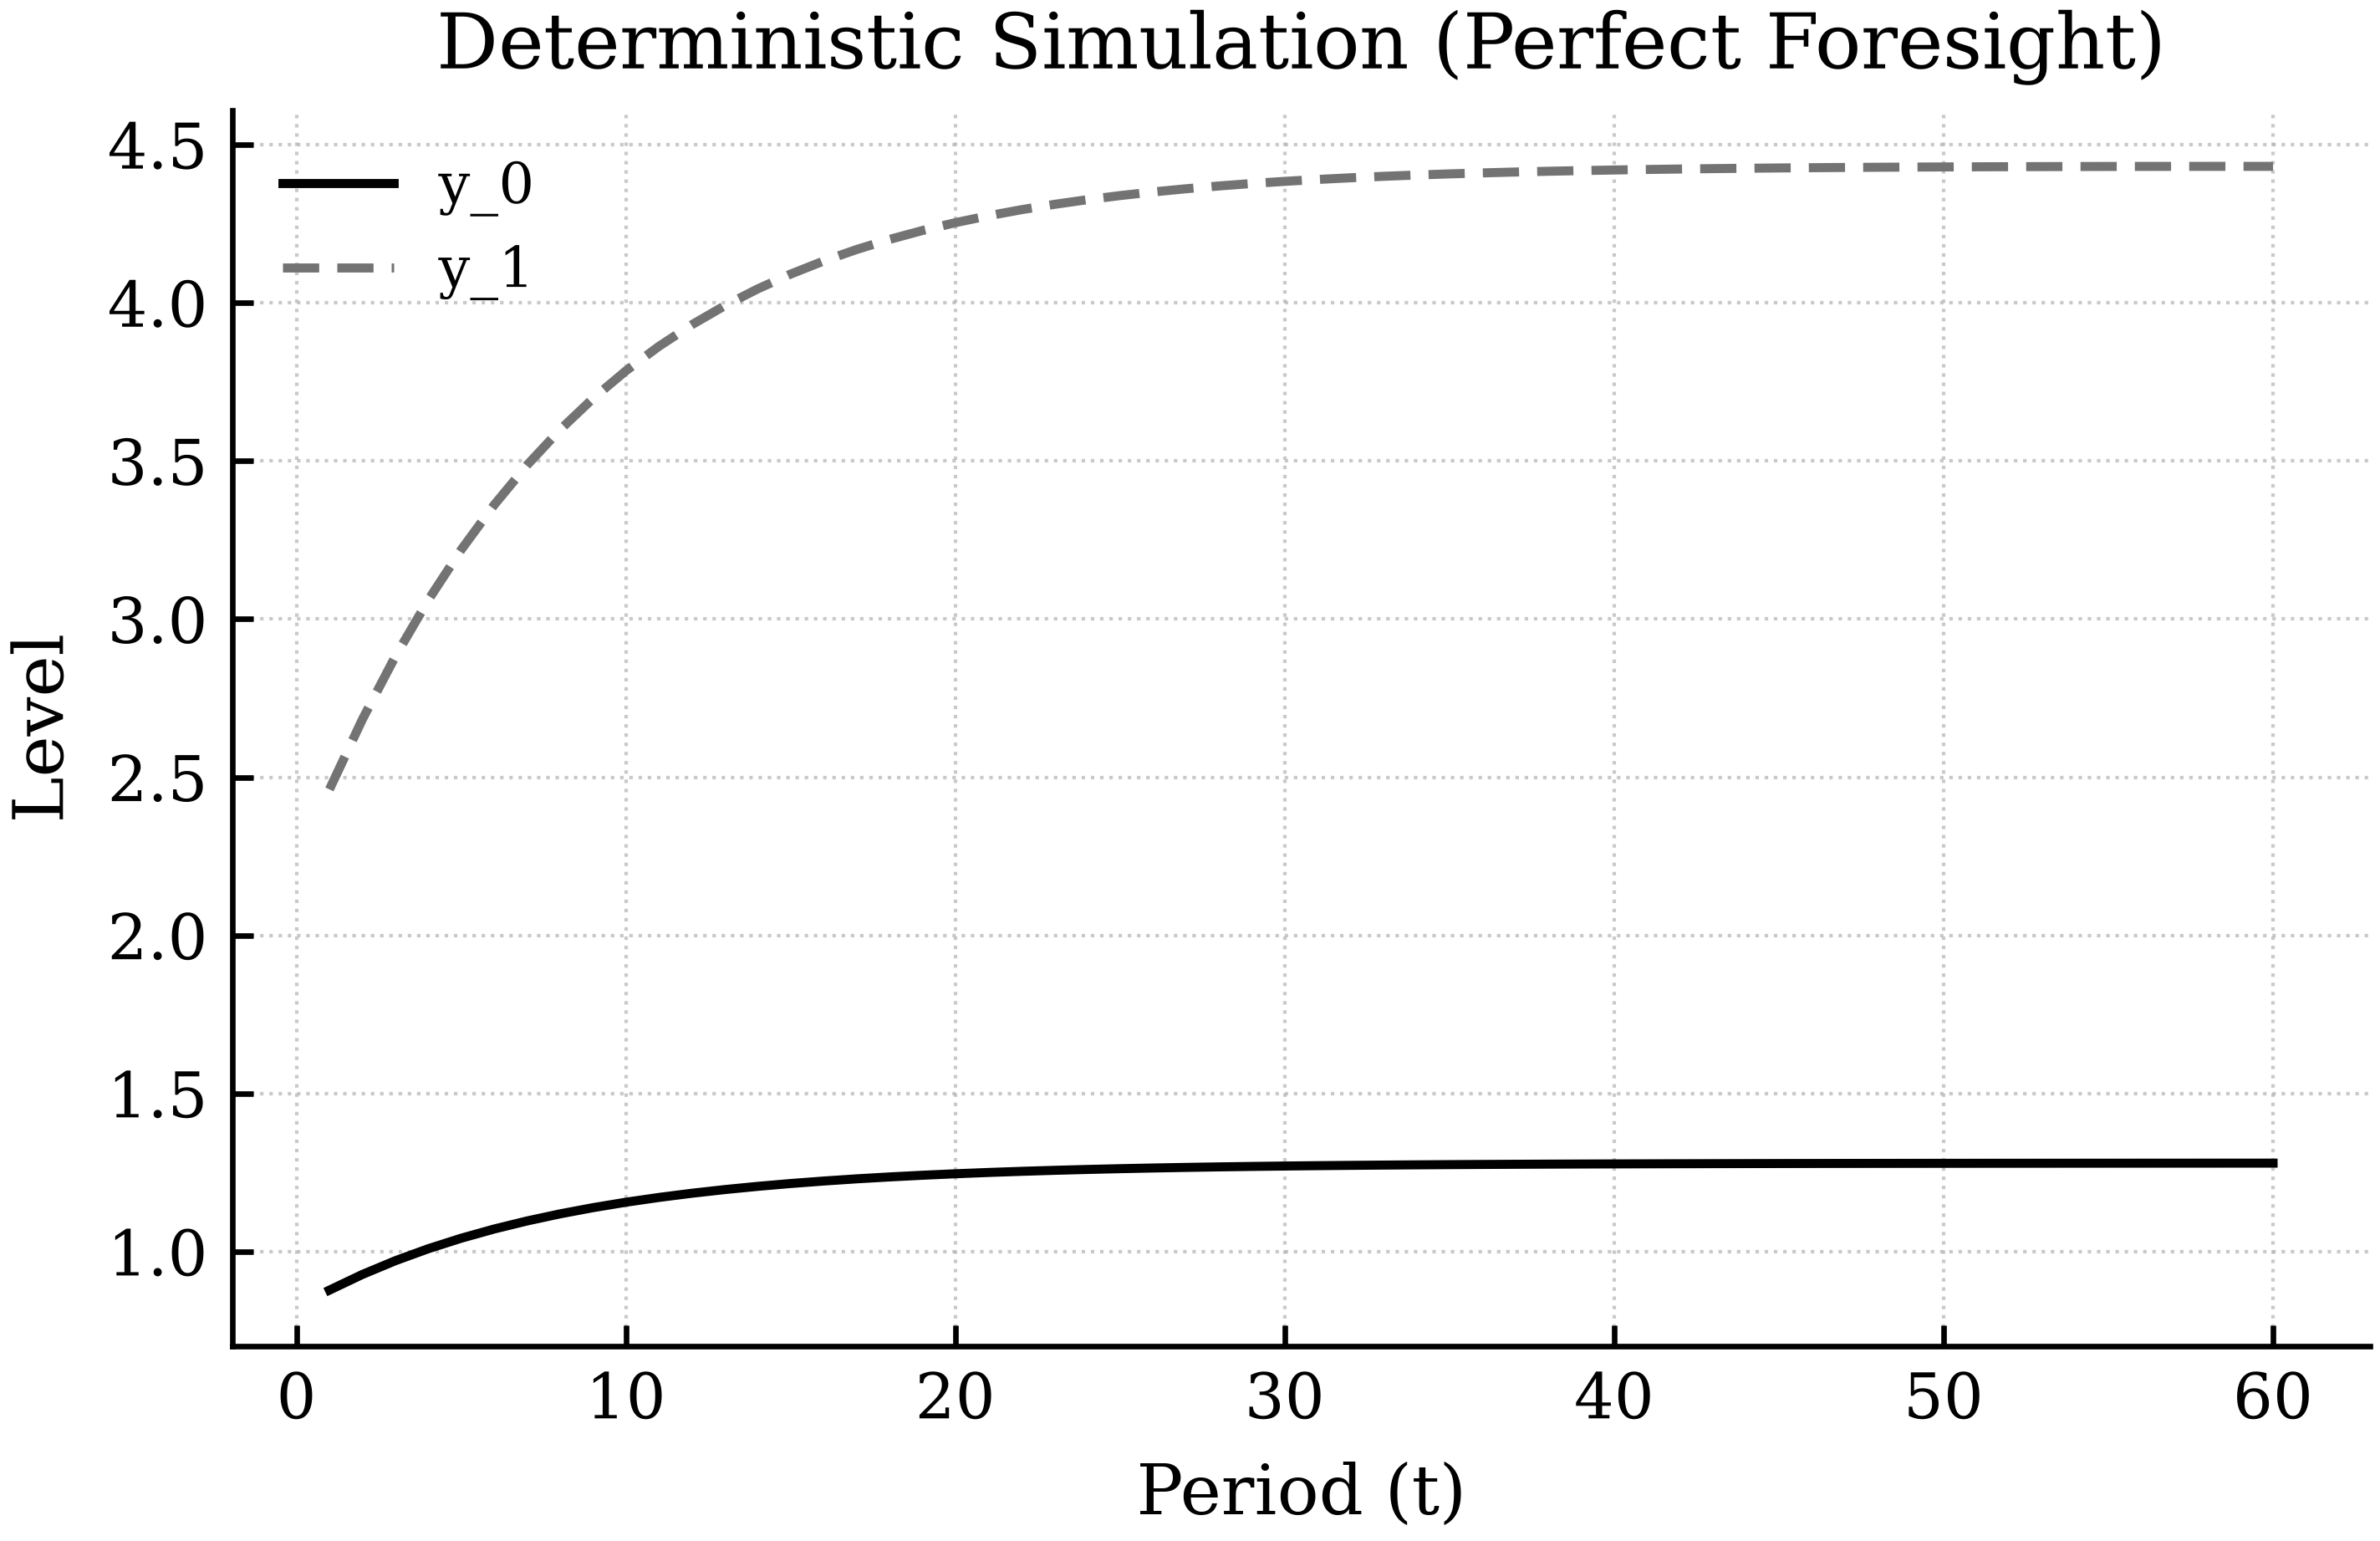

In [6]:
alpha, beta, delta, sigma = 0.33, 0.96, 0.08, 1.0
k_ss = ((1.0 / beta - (1.0 - delta)) / alpha) ** (1.0 / (alpha - 1.0))
c_ss = k_ss ** alpha - delta * k_ss
y_ss = np.array([c_ss, k_ss])

def ramsey_eqs(lead, curr, lag, exo):
    c_t, k_t = curr[0], curr[1]
    c_p, k_p = lead[0], lead[1]
    k_m = lag[1]
    A_t = exo[0]
    
    euler = c_t ** (-sigma) - beta * (c_p ** (-sigma)) * (alpha * A_t * (k_t ** (alpha - 1.0)) + 1.0 - delta)
    resource = k_t - (A_t * (k_m ** alpha) + (1.0 - delta) * k_m - c_t)
    return np.array([euler, resource])

y_init = np.array([c_ss * 0.7, 0.5 * k_ss])
exo_path = np.ones((60, 1))

pf_res = solve_perfect_foresight(ramsey_eqs, y_init=y_init, y_ss=y_ss, exogenous_path=exo_path, n_periods=60)
print(pf_res.summary())

fig_pf = pf_res.plot()
plt.show()

## 6. Estimación Bayesiana DSGE Nativa vía Metropolis-Hastings

puremacro 2.6.0 estima modelos `.mod` de forma nativa utilizando sus distribuciones a priori (`estimated_params`) y series observadas (`varobs`).
Al invocar `m.estimate(data)`, el motor evalúa la verosimilitud exacta del modelo de espacio de estados mediante el filtro de Kalman y ejecuta el muestreo MCMC Random Walk Metropolis-Hastings.

/Users/jalonso/Documents/RESEARCH/puremacro/puremacro/dsge/estimate.py:587: UserWarning: estimate_dsge: the mode search terminated at the starting point without moving ("mode search skipped (method='none')"); initial_params is being reported as the mode but has NOT been shown to be one. Supply a better initial_params, or treat `mode` and `mode_hessian_inv` as descriptive only.
  warnings.warn(


/Users/jalonso/Documents/RESEARCH/puremacro/puremacro/dsge/estimate.py:706: UserWarning: estimate_dsge: chain 0 accept_rate=0.525 outside [0.10, 0.50]; mixing may be poor.
  warnings.warn(


                mean       std        q5       q50       q95      mode
SE_ea       0.565648  0.060870  0.495304  0.552475  0.665061  0.461800
SE_eb       0.248993  0.042857  0.185388  0.249326  0.314121  0.181851
SE_eg       0.504916  0.037681  0.452150  0.500185  0.567145  0.609000
SE_eqs      0.558352  0.096283  0.432124  0.560874  0.708984  0.460170
SE_em       0.351303  0.104575  0.204007  0.312837  0.517358  0.239700
SE_epinf    0.265361  0.025623  0.227279  0.265595  0.304872  0.145500
SE_ew       0.348661  0.060834  0.227968  0.364021  0.432954  0.208900
crhoa       0.968806  0.013817  0.953337  0.966870  0.988594  0.967600
crhob       0.272529  0.008595  0.262600  0.274153  0.282488  0.270300
crhog       0.986785  0.004286  0.979723  0.986977  0.991895  0.993000
crhoqs      0.570205  0.007709  0.559377  0.570483  0.581543  0.572400
crhoms      0.309139  0.004036  0.303453  0.309984  0.316589  0.300000
crhopinf    0.859802  0.004117  0.851496  0.861342  0.864708  0.869200
crhow 

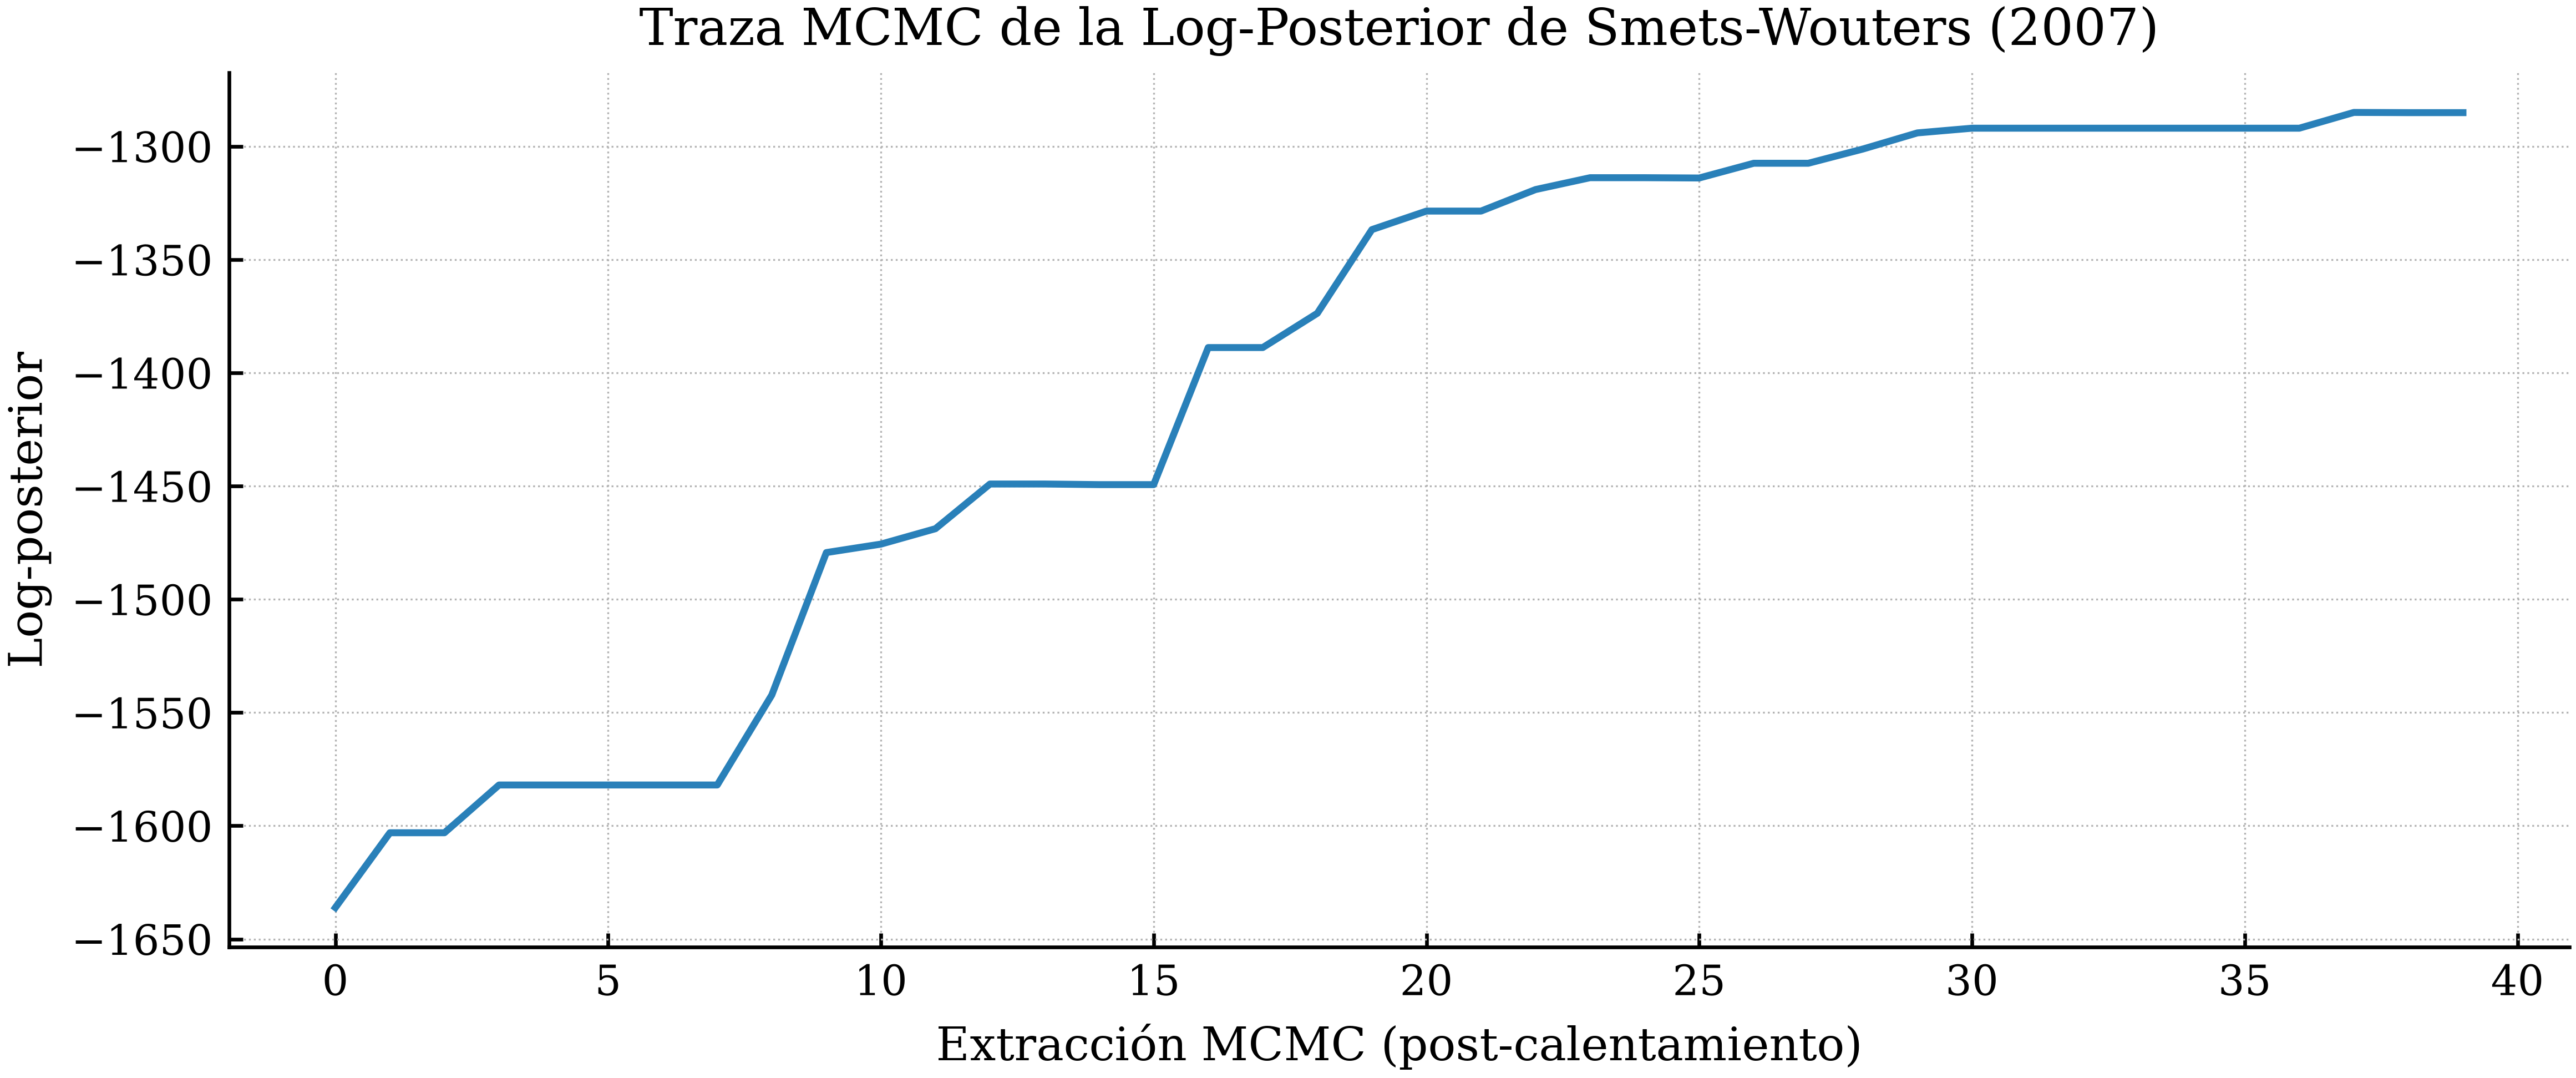

In [7]:
bayes_res = m.estimate(
    data,
    mode_compute="none",
    n_draws=40,
    burn_in=20,
    seed=42,
)

print(bayes_res.summary())

# Gráfico de la traza MCMC de la log-posterior
fig_bayes, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(bayes_res.log_posterior_trace[0], color="#2980b9", lw=1.5)
ax.set_xlabel("Extracción MCMC (post-calentamiento)")
ax.set_ylabel("Log-posterior")
ax.set_title("Traza MCMC de la Log-Posterior de Smets-Wouters (2007)")
plt.tight_layout()
plt.show()

## Conclusiones

Con `puremacro`:
1. **Cero dependencias de MATLAB / C++**: Resolución y estimación de modelos DSGE directamente en Python.
2. **Paridad total con Dynare**: Carga de archivos `.mod`, reglas de decisión, momentos teóricos, FEVD, descomposición de shocks, OccBin y previsión perfecta.
3. **Ejecución universal**: Funciona sin modificaciones en Apple Silicon, Linux, Windows y navegadores con JupyterLite.